In [1]:
import drjit as dr
import cupy as xp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th 
from drjit.cuda import Array2f, Array1f, ArrayXf, Float, TensorXf

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

In [2]:
import sys
sys.path.append("src")
import xrt_toolkit as xtk

### 3D volume (5, 5, 5) and geometry

In [3]:
size = 5
detector_count = 100
x = xp.zeros((size, size, size), dtype=xp.float32)
x[2, 2, 2] = 1.0

angles = xp.linspace(0.4, xp.pi, 1, dtype=xp.float32, endpoint=False)
detector_spec = xtk.DetectorSpec((5,5), (detector_count, detector_count))
ray_spec = xtk.parallel_beam(Float(angles), detector_spec)

knot_spec = xtk.UniformSpec(start=(-(size//2), -(size//2), -(size//2)), step=(1,1,1), num=(size, size, size))

In [4]:
order = 0
x_dr = Float(x.reshape(-1))
y_dr = xtk.xrt_struct_apply(ray_spec, knot_spec, 1, x_dr)


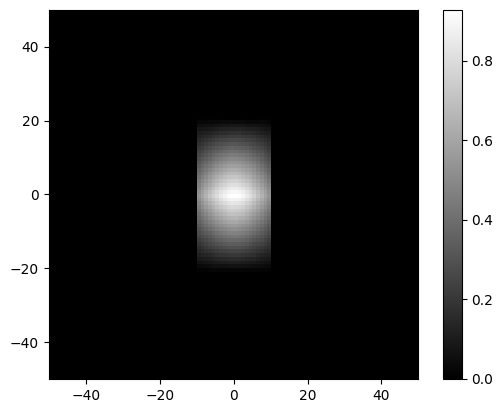

In [5]:
plt.imshow(np.asarray(y_dr).reshape(len(angles), detector_count, detector_count)[0], cmap='gray', extent=[-detector_count/2, detector_count/2, -detector_count/2, detector_count/2])
plt.colorbar()

In [ ]:
import torch
import torch.nn as nn

class SplineNN(nn.Module):
    def __init__(self, input_dim=4, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 16)
        self.fc4 = nn.Linear(16, 16)
        self.fc5 = nn.Linear(16, output_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        return self.fc5(x)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SplineNN(input_dim=4, output_dim=1).to(device)
model.load_state_dict(torch.load('3D_boxsplines_model.pth', map_location=device))
model.eval()

<All keys matched successfully>